# Лаба 1.02

### Математические функции и XML

In [2]:
from meas import *
from math import *

from pprint import pprint
from lxml import etree

# Парсим XML
dom = etree.parse('latex.xml')
xml = dom.getroot()

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoLocator
import numpy as np

### Результаты измерений

In [3]:
# (Таблица 1) Погрешности приборов: [delta_x] м; [delta_h] мм; [delta_t] с
delta_x = 0.005
delta_h = 0.5 # мм
delta_t = 0.1
# (Таблица 2) Горизонтальное положение: [x] м, [x'] м; [h] мм, [h'] мм
x = 0.220
X = 1.000 
h0 = 180
H0 = 181
# (Таблица 3) Измерения задания 1: [x1] м | [x2] м | [t1] с | [t2] с
data1 = [
    (0.15, 0.40, 1.3, 2.4),
    (0.15, 0.50, 1.2, 2.7),
    (0.15, 0.70, 1.3, 3.3),
    (0.15, 0.90, 1.2, 3.7),
    (0.15, 1.10, 1.3, 4.2)
]
# (Таблица 4) Измерения задания 2: [h1] мм | [h2] мм | [t1] с | [t2] с
data2 = [
    (191, 182, [1.2, 1.2, 1.2, 1.3, 1.3], [4.2, 4.2, 4.2, 4.2, 4.2]),
    (200, 183, [0.9, 0.9, 0.9, 0.9, 0.9], [3.0, 3.0, 3.0, 3.0, 3.0]),
    (210, 184, [0.7, 0.7, 0.7, 0.7, 0.7], [2.4, 2.4, 2.4, 2.4, 2.5]),
    (219, 184, [0.6, 0.6, 0.6, 0.6, 0.6], [2.1, 2.1, 2.1, 2.1, 2.1]),
    (229, 185, [0.5, 0.5, 0.6, 0.6, 0.5], [1.9, 1.9, 1.9, 1.9, 1.9])
]
# Координаты ворот задания 2
lol_x1 = 0.15
lol_x2 = 1.10

### Рассчёты

##### Задание 1.1 и 1.3

In [4]:
Y, Z = [], []
for i, (x1, x2, t1, t2) in enumerate(data1):
    Y.append(Measurement(x2-x1, (2*sqrt(2)/3) * delta_x))
    Z.append(Measurement((t2**2 + t1**2) / 2, (2/3) * delta_t * sqrt(t2**2 + t1**2)))

print(Y, Z)


[0.250±0.005 ε = 1.9, 0.350±0.005 ε = 1.3, 0.550±0.005 ε = 0.9, 0.750±0.005 ε = 0.6, 0.950±0.005 ε = 0.5] [3.72±0.18 ε = 5.0, 4.36±0.20 ε = 5.0, 6.29±0.24 ε = 3.8, 7.56±0.26 ε = 3.4, 9.67±0.29 ε = 3.0]


In [5]:
N = len(data1)
value_a = sum(Y[i].value*Z[i].value for i in range(N)) / sum(Z[i].value**2 for i in range(N))
sigma_a = sqrt(sum((Y[i].value-value_a*Z[i].value)**2 for i in range(N)) / sum(Z[i].value**2 for i in range(N)) / (N - 1))
a = Measurement(value_a, 2*sigma_a)
print(a.rounded)
print(sigma_a)

0.093±0.009 ε = 10.0
0.00452584237699824


In [27]:
def calculate_coefficients(x, y):
    """Вычисляет коэффициенты A и B по МНК для модели a = A + B·sin α"""
    N = len(x)
    Sa = sum(x)
    Ss = sum(y)
    Sas = sum(v*w for v, w in zip(x, y))
    Ss2 = sum(s**2 for s in y)
    
    B = (N*Sas - Sa*Ss) / (N*Ss2 - Ss**2)
    A = (Sa - B*Ss) / N
    return A, B

nA, nB = calculate_coefficients([point.value for point in Y], [point.value for point in Z])
print(nA, nB)
print(a.value_)
print([point.value for point in Y], [point.value_ for point in Z])

-0.17662922791127614 0.11813753606191078
0.09311683176838599
[0.25, 0.35, 0.55, 0.75, 0.95] [3.725, 4.365, 6.289999999999999, 7.565, 9.665000000000001]


##### Задание 1.2 и 1.4

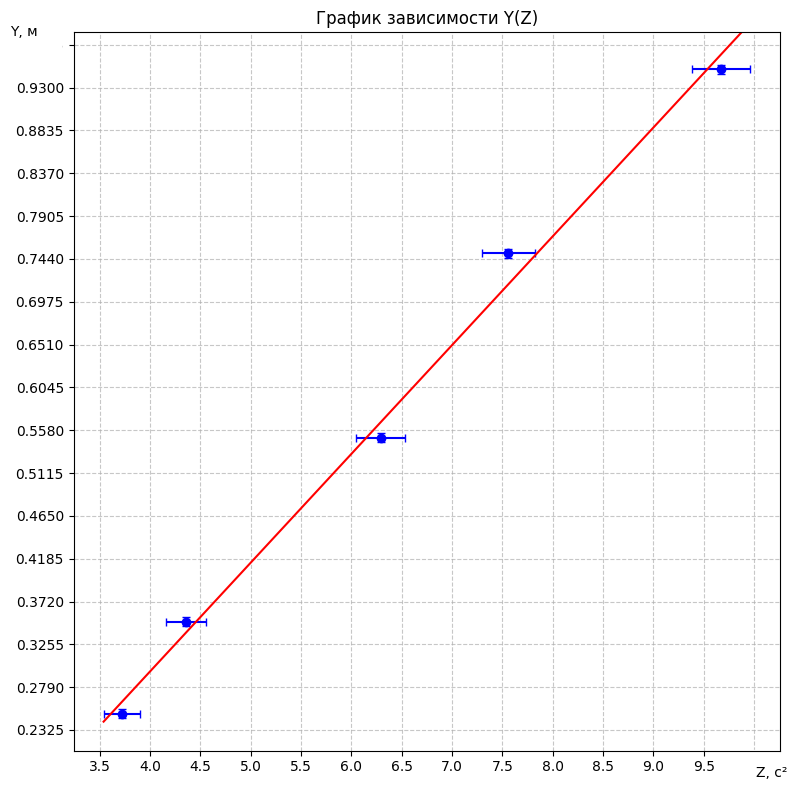

In [ ]:
def plot_dependency(nA, nB, Y, Z):
    # Считаем границы
    Z_min, Z_max = min(Z), max(Z)
    Y_min, Y_max = min(Y), max(Y)
    
    # Создаем фигуру и оси
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Экспериментальные точки с погрешностями
    ax.errorbar(x=[point.value for point in Z], 
                y=[point.value for point in Y], 
                xerr=[point.delta for point in Z], 
                yerr=[point.delta for point in Y],
                fmt='o', color='blue', markersize=6,
                label='Экспериментальные точки', capsize=3)
    
    # Теоретическая зависимость
    Z_range = np.linspace(Z_min.value - Z_min.delta, Z_max.value + Z_max.delta)
    Y_theor = nB * Z_range + nA
    ax.plot(Z_range, Y_theor, 'r-', label=f'Теория: Y = {a.value:.2f}Z')
    
    # Устанавливаем пределы осей
    ax.set_xlim(Z_min.value - Z_min.delta - 0.05*(Z_max.value - Z_min.value), Z_max.value + Z_max.delta + 0.05*(Z_max.value - Z_min.value))
    ax.set_ylim(Y_min.value - Y_min.delta - 0.05*(Y_max.value - Y_min.value), Y_max.value + Y_max.delta + 0.05*(Y_max.value - Y_min.value))
    # Подписи осей
    plt.xlabel("Z, с²", x=1.01, ha='right', va='bottom', 
               bbox={
                 'boxstyle': 'square',  # стиль рамки (круглая/прямоугольная)
                 'facecolor': 'white', # цвет фона
                 'edgecolor': 'white', # цвет рамки
                 'pad': 1.15            # отступ текста от рамки
               })
    plt.ylabel("Y, м", y=1.01, ha='left', va='top', rotation=0, 
               bbox={
                 'boxstyle': 'square',  # стиль рамки (круглая/прямоугольная)
                 'facecolor': 'white', # цвет фона
                 'edgecolor': 'white', # цвет рамки
                 'pad': 1.65            # отступ текста от рамки
               })
    # Настройка делений сетки
    tick_step=0.5
    if tick_step:
        ax.xaxis.set_major_locator(MultipleLocator(tick_step))
        ax.yaxis.set_major_locator(MultipleLocator(a.value*tick_step))
    else:
        ax.xaxis.set_major_locator(AutoLocator())
        ax.yaxis.set_major_locator(AutoLocator())
    # Включаем сетку
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    # Добавляем заголовок
    plt.title('График зависимости Y(Z)')
    
    plt.tight_layout()
    plt.show()


plot_dependency(nA, nB, Y, Z)

##### Задание 2.1 - 2.4

In [8]:
sin_alpha = []
for (h, H, t1, t2) in data2:
    # print(h0, H0, h, H)
    sa = abs( ((h0 - h) - (H0 - H)) / (X*1000 - x*1000) )
    # print(sa)
    sin_alpha.append(round_to_significant(sa, 2))
    # sin_alpha.append(sa)

print(sin_alpha)

[0.013, 0.023, 0.035, 0.046, 0.058]


In [9]:
average_t1 = []
average_t2 = []
for (h, H, t1_values, t2_values) in data2:
    t1 = DirectMultipleMeasurement(t1_values, delta_t)
    t2 = DirectMultipleMeasurement(t2_values, delta_t)
    average_t1.append(t1)
    average_t2.append(t2)
    
pprint(average_t1)
pprint(average_t2)
print(average_t1[0].debug())

[1.2±0.1 ε = 8.0,
 0.90±0.07 ε = 7.0,
 0.70±0.07 ε = 10.0,
 0.60±0.07 ε = 11.0,
 0.5±0.1 ε = 18.0]
[4.20±0.07 ε = 1.6,
 3.00±0.07 ε = 2.2,
 2.42±0.09 ε = 3.6,
 2.10±0.07 ε = 3.2,
 1.90±0.07 ε = 3.5]

N = 5
values = [1.2, 1.2, 1.2, 1.3, 1.3]
average = 1.2
average_ = 1.24
sigma_ = 0.024494897427831803
delta = 0.1
delta_ = 0.09529682284548868
delta_instrumental = 0.1
delta_random_ = 0.06809581484937241
student = 2.78
epsilon = 8.0
epsilon_ = 7.685227648829733


In [10]:
average_a = []
for i in range(len(data2)):
    t1, t2 = average_t1[i], average_t2[i]
    avr_a = 2 * (lol_x2 - lol_x1) / (t2.value_**2 - t1.value_**2)
    del_a = avr_a * sqrt((2*delta_x**2)/(lol_x2 - lol_x1)**2 + 4*((t1.value_*t1.delta_)**2 + (t2.value_*t2.delta_)**2)/(t2.value_**2 - t1.value_**2)**2)
    average_a.append(Measurement(avr_a, del_a))
    
pprint(average_a)

[0.118±0.005 ε = 3.8,
 0.232±0.012 ε = 5.0,
 0.354±0.029 ε = 8.0,
 0.469±0.034 ε = 7.0,
 0.57±0.05 ε = 8.0]


##### Задание 2.5 - 2.7

In [11]:
avg_a = [t.value_ for t in average_a]

def calculate_coefficients(a, sin_alpha):
    """Вычисляет коэффициенты A и B по МНК для модели a = A + B·sin α"""
    N = len(a)
    Sa = sum(a)
    Ss = sum(sin_alpha)
    Sas = sum(v*w for v, w in zip(a, sin_alpha))
    Ss2 = sum(s**2 for s in sin_alpha)
    
    B = (N*Sas - Sa*Ss) / (N*Ss2 - Ss**2)
    A = (Sa - B*Ss) / N
    return A, B

A, B = calculate_coefficients(avg_a, sin_alpha)
print(A, B)

-0.005499929937626158 10.132802678257653


In [12]:
N = len(avg_a)
d = [avg_a[i] - (A + B*sin_alpha[i]) for i in range(N)]
sum_d2 = sum(d[i]**2 for i in range(N))
D = sum(sin_alpha[i]**2 for i in range(N)) - (1/N)*(sum(sin_alpha))**2
sigma_g = sqrt(sum_d2/D/(N-2))

g = Measurement(B, 2*sigma_g)
print(g)
print(g.format())
print(d, D, sigma_g)

10.1±0.5 ε = 5.0 (10.132802678258 Δ = 0.537677978 ε = 5.306310555)
10.1\pm0.5
[-0.008231671811360822, 0.004435700327932168, 0.0049066960674216675, 0.008526809206909958, -0.009637533790903041] 0.0012779999999999979 0.2688389890174544


In [13]:
g_table = 9.81908
g_table_delta = phys_round(abs(g.value - g_table))
g_table_epsilon = phys_round(g_table_delta / g.value * 100)
print(f'g табл = {g_table}, Δ = {g_table_delta}, ε = {g_table_epsilon}')

g табл = 9.81908, Δ = 0.28, ε = 2.8


##### Задание 2.8 - 2.9

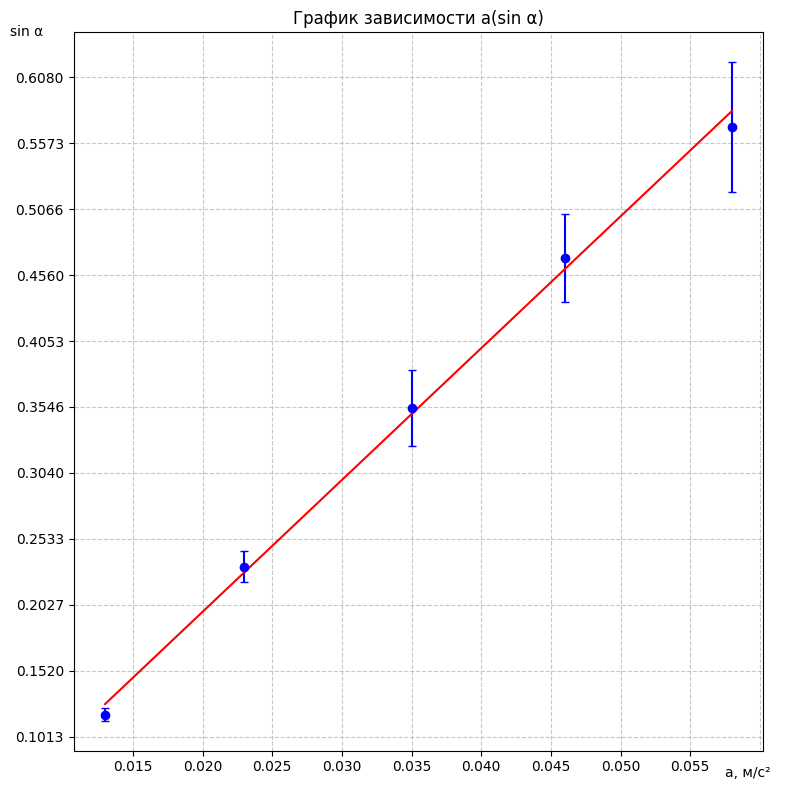

In [14]:
def plot_dependency_2(A, B, sin_alpha, average_a):
    # Считаем границы
    X_min, X_max = min(sin_alpha), max(sin_alpha)
    Y_min, Y_max = min(average_a), max(average_a)

    # Создаем фигуру и оси
    fig, ax = plt.subplots(figsize=(8, 8))

    # Экспериментальные точки с погрешностями
    ax.errorbar(x=sin_alpha, 
                y=[point.value for point in average_a], 
                yerr=[point.delta for point in average_a],
                fmt='o', color='blue', markersize=6,
                label='Экспериментальные точки', capsize=3)

    # Теоретическая зависимость
    Z_range = np.linspace(X_min, X_max)
    Y_theor = A + B * Z_range
    ax.plot(Z_range, Y_theor, 'r-', label=f'Теория: Y = {A:.4f} + {B:.4f} * sin α')

    # Устанавливаем пределы осей
    ax.set_xlim(X_min - 0.05*(X_max - X_min), X_max + 0.05*(X_max - X_min))
    ax.set_ylim(Y_min.value - Y_min.delta - 0.05*(Y_max.value - Y_min.value), Y_max.value + Y_max.delta + 0.05*(Y_max.value - Y_min.value))
    # Подписи осей
    plt.xlabel("a, м/с²", x=1.01, ha='right', va='bottom', 
               bbox={'boxstyle': 'square', 'facecolor': 'white', 'edgecolor': 'white', 'pad': 1.15})
    plt.ylabel("sin α", y=1.01, ha='left', va='top', rotation=0, 
               bbox={'boxstyle': 'square', 'facecolor': 'white', 'edgecolor': 'white', 'pad': 1.65})
    # Настройка делений сетки
    tick_step=0.005
    if tick_step:
        ax.xaxis.set_major_locator(MultipleLocator(tick_step))
        ax.yaxis.set_major_locator(MultipleLocator(B * tick_step))
    else:
        ax.xaxis.set_major_locator(AutoLocator())
        ax.yaxis.set_major_locator(AutoLocator())
    # Включаем сетку
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    # Добавляем заголовок
    plt.title('График зависимости a(sin α)')

    plt.tight_layout()
    plt.show()
    
plot_dependency_2(A, B, sin_alpha, average_a)

### Latex

In [15]:
table2 = xml.find('table2_start').text + f"${Measurement(x, delta_x).format()}$ & ${Measurement(X, delta_x).format()}$ & ${Measurement(h0, delta_h).format()}$ & ${Measurement(H0, delta_h).format()}$" + xml.find('table2_finish').text

print(table2)

\begin{table}[h]
\centering
\caption{Фиксированные координаты (горизонтальное положение)}
\label{tab:measurements}
\begin{tabular}{|c|c|c|c|}
\hline
\(x_1, \, \text{м}\) & \(x_2, \, \text{м}\) & \(h_0, \, \text{мм}\) & \(h_0', \, \text{мм}\) \\ \hline
$0.220\pm0.005$ & $1.000\pm0.005$ & $180.0\pm0.5$ & $181.0\pm0.5$ \\ \hline
\end{tabular}
\end{table}


In [16]:
table3 = xml.find('table3_start').text
for (i, ((x1, x2, t1, t2), y, z)) in enumerate(zip(data1, Y, Z)):
    table3 += f'{i + 1} & {x1} & {x2} & {t1} & {t2} & ${y.format()}$ & ${z.format()}$ \\\\ \\hline\n'
table3 += xml.find('table3_finish').text

print(table3)

\begin{table}[h]
\centering
\caption{Результаты прямых измерений (Задание 1)}
\label{tab:measurements}
\begin{tabular}{|c|c|c|c|c|c|c|}
\hline
№ & \multicolumn{4}{c|}{Измеренные величины} & \multicolumn{2}{c|}{Рассчитанные величины} \\
\cline{2-7} 
& \(x_1, \, \text{м}\) & \(x_2, \, \text{м}\) & \(t_1, \, \text{c}\) & \(t_2, \, \text{c}\) & \(x_2 - x_1, \, \text{м}\) & \(\frac{t_2^2 - t_1^2}{2}, \, \text{c}^2\) \\
\hline1 & 0.15 & 0.4 & 1.3 & 2.4 & $0.250\pm0.005$ & $3.72\pm0.18$ \\ \hline
2 & 0.15 & 0.5 & 1.2 & 2.7 & $0.350\pm0.005$ & $4.36\pm0.20$ \\ \hline
3 & 0.15 & 0.7 & 1.3 & 3.3 & $0.550\pm0.005$ & $6.29\pm0.24$ \\ \hline
4 & 0.15 & 0.9 & 1.2 & 3.7 & $0.750\pm0.005$ & $7.56\pm0.26$ \\ \hline
5 & 0.15 & 1.1 & 1.3 & 4.2 & $0.950\pm0.005$ & $9.67\pm0.29$ \\ \hline
\end{tabular}
\end{table}


In [17]:
inacc_YZ = xml.findall('inaccuracy_YZ')
inaccuracy_YZ = inacc_YZ[0].text + str(delta_x) + inacc_YZ[1].text + str(delta_x) + inacc_YZ[2].text
inaccuracy_YZ += ", ".join(f"$\\varepsilon_{{Y_{i+1}}}={y.epsilon}\\%$" for i, y in enumerate(Y))
inaccuracy_YZ += inacc_YZ[3].text + str(delta_t) + inacc_YZ[4].text
inaccuracy_YZ += ", ".join(f"$\\Delta_{{Z_{i+1}}}={z.delta} {{c^2}}$" for i, z in enumerate(Z))
inaccuracy_YZ += inacc_YZ[5].text
inaccuracy_YZ += ", ".join(f"$\\varepsilon_{{Z_{i+1}}}={z.epsilon}\\%$" for i, z in enumerate(Z))
inaccuracy_YZ += '.'
print(inaccuracy_YZ)

Абсолютная погрешность для $Y=x_2-x_1$ (при $\Delta_{x_1}=\Delta_{x_2}=\frac{2}{3}\Delta_{x\text{и}} = 0.005мм$): 
{\fontsize{13}{13}\selectfont\begin{equation*}
    \Delta_Y =
    \sqrt{(\frac{\partial Y}{\partial x_1}\Delta_{x_1})^2+(\frac{\partial Y}{\partial x_2}\Delta_{x_2})^2} =
    \sqrt{(-\frac{2}{3}\Delta_{x\text{и}})^2+(\frac{2}{3}\Delta_{x\text{и}})^2} = 
    \frac{2\sqrt{2}}{3}\Delta_{x\text{и}} \approx 0.005\text{мм}
\end{equation*}}

Относительные погрешности $\varepsilon_Y=\frac{\Delta_Y}{Y}\cdot100\%$:

$\varepsilon_{Y_1}=1.9\%$, $\varepsilon_{Y_2}=1.3\%$, $\varepsilon_{Y_3}=0.9\%$, $\varepsilon_{Y_4}=0.6\%$, $\varepsilon_{Y_5}=0.5\%$.

Абсолютные погрешности для $Z= \frac{t_2^2-t_1^2}{2}$  ($\Delta_{t_1}=\Delta_{t_2}=\frac{2}{3}\Delta_{t\text{и}} = 0.1c$): 

{\fontsize{13}{13}\selectfont\begin{equation*}
    \Delta_Z =
    \sqrt{(\frac{\partial Z}{\partial t_1}\Delta_{t_1})^2+(\frac{\partial Z}{\partial t_2}\Delta_{t_2})^2} =
    \sqrt{(t_1\Delta_{t_1})^2+(t_1\Delta_{t

In [18]:
calculations_a = f"""По формулам были посчитаны $a = {a.value}\\text{{м}}/\\text{{c}}^2$ и $\\sigma_a \\approx {round_to_significant(sigma_a, 2)}$.
Затем погрешности $\\delta_a = {a.delta}\\text{{м}}/\\text{{c}}^2$ и $\\varepsilon_a = {a.epsilon}\\%$ Результат:
"""
result_a =f"""\\begin{{equation*}}
a = ({a.format()})\\text{{м}}/\\text{{c}}^2, \\quad \\varepsilon_a = {a.epsilon}\\%, \\quad \\alpha=0.90
\\end{{equation*}}"""
print(calculations_a + result_a)

По формулам были посчитаны $a = 0.093\text{м}/\text{c}^2$ и $\sigma_a \approx 0.0045$.
Затем погрешности $\delta_a = 0.009\text{м}/\text{c}^2$ и $\varepsilon_a = 10.0\%$ Результат:
\begin{equation*}
a = (0.093\pm0.009)\text{м}/\text{c}^2, \quad \varepsilon_a = 10.0\%, \quad \alpha=0.90
\end{equation*}


In [19]:
table4 = xml.find('table_4_start').text
for i, (h1, h2, t1, t2) in enumerate(data2):
    table4 += f'\\multirow{{5}}{{*}}{{{i + 1}}} & \\multirow{{5}}{{*}}{{{h1}}} & \\multirow{{5}}{{*}}{{{h2}}} & 1 & {t1[0]} & {t2[0]} '
    for j in range(1, len(t1)):
        table4 += f'\\\\ \\cline{{4-6}}\n& & & {j + 1} & {t1[j]} & {t2[j]} '
    table4 += '\\\\ \\hline\n'
table4 += xml.find('table_4_finish').text
print(table4)

\begin{table}[h]
\centering
\caption{Результаты прямых измерений (Задание 2)}
\label{tab:experiment2}
\begin{tabular}{|c|c|c|c|c|c|}
\hline
$ N_{\text{ПЛ}} $ & $ h, \, \text{мм} $ & $ h', \, \text{мм} $ & № &  $t_1, \, \text{c}$ & $t_2, \, \text{c}$ \\
\hline
\multirow{5}{*}{1} & \multirow{5}{*}{191} & \multirow{5}{*}{182} & 1 & 1.2 & 4.2 \\ \cline{4-6}
& & & 2 & 1.2 & 4.2 \\ \cline{4-6}
& & & 3 & 1.2 & 4.2 \\ \cline{4-6}
& & & 4 & 1.3 & 4.2 \\ \cline{4-6}
& & & 5 & 1.3 & 4.2 \\ \hline
\multirow{5}{*}{2} & \multirow{5}{*}{200} & \multirow{5}{*}{183} & 1 & 0.9 & 3.0 \\ \cline{4-6}
& & & 2 & 0.9 & 3.0 \\ \cline{4-6}
& & & 3 & 0.9 & 3.0 \\ \cline{4-6}
& & & 4 & 0.9 & 3.0 \\ \cline{4-6}
& & & 5 & 0.9 & 3.0 \\ \hline
\multirow{5}{*}{3} & \multirow{5}{*}{210} & \multirow{5}{*}{184} & 1 & 0.7 & 2.4 \\ \cline{4-6}
& & & 2 & 0.7 & 2.4 \\ \cline{4-6}
& & & 3 & 0.7 & 2.4 \\ \cline{4-6}
& & & 4 & 0.7 & 2.4 \\ \cline{4-6}
& & & 5 & 0.7 & 2.5 \\ \hline
\multirow{5}{*}{4} & \multirow{5}{*}{219} & \mu

In [20]:
table5 = xml.find('table_5_start').text
for i in range(len(data2)):
    table5 += f'{i + 1} & {sin_alpha[i]} & ${average_t1[i].format()}$ & ${average_t2[i].format()}$ & ${average_a[i].format()}$ \\\\ \\hline\n'
table5 += xml.find('table_5_finish').text

print(table5)

\begin{table}[H]
\centering
\caption{Результаты расчетов (Задание 2)}
\label{tab:calculations}
\begin{tabular}{|c|c|c|c|c|}
\hline
$N_{\text{ПЛ}}$ & $\sin \alpha$ & $\langle t_1 \rangle \pm \Delta t_1, \, \text{c}$ & $\langle t_2 \rangle \pm \Delta t_2, \, \text{c}$ & $\langle a \rangle \pm \Delta a, \, \frac{\text{м}}{\text{c}^2}$ \\
\hline
1 & 0.013 & $1.2\pm0.1$ & $4.20\pm0.07$ & $0.118\pm0.005$ \\ \hline
2 & 0.023 & $0.90\pm0.07$ & $3.00\pm0.07$ & $0.232\pm0.012$ \\ \hline
3 & 0.035 & $0.70\pm0.07$ & $2.42\pm0.09$ & $0.354\pm0.029$ \\ \hline
4 & 0.046 & $0.60\pm0.07$ & $2.10\pm0.07$ & $0.469\pm0.034$ \\ \hline
5 & 0.058 & $0.5\pm0.1$ & $1.90\pm0.07$ & $0.57\pm0.05$ \\ \hline
\end{tabular}
\end{table}


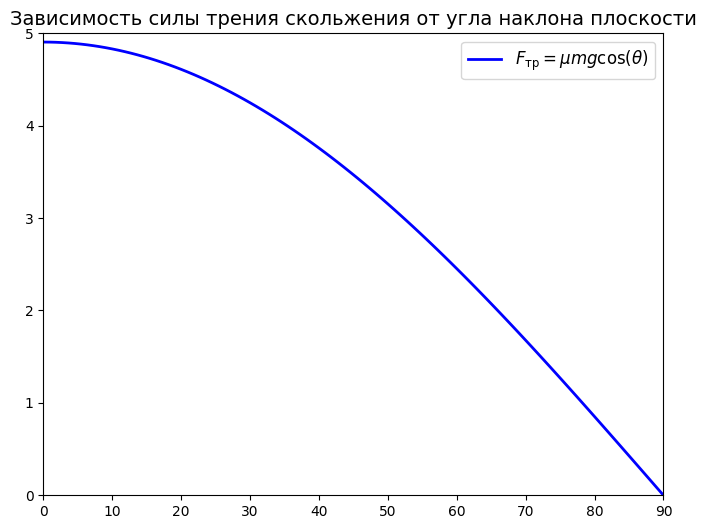

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
mu = 0.5  # Коэффициент трения скольжения
m = 1.0   # Масса тела (кг)
g = 9.81  # Ускорение свободного падения (м/с²)

# Углы наклона плоскости от 0 до 90 градусов
theta = np.linspace(0, 90, 100)  # Углы в градусах
theta_rad = np.deg2rad(theta)    # Переводим углы в радианы

# Вычисление силы трения
F_friction = mu * m * g * np.cos(theta_rad)

# Построение графика
plt.figure(figsize=(8, 6))
plt.plot(theta, F_friction, label=r'$F_{\text{тр}} = \mu m g \cos(\theta)$', color='blue', linewidth=2)
plt.title('Зависимость силы трения скольжения от угла наклона плоскости', fontsize=14)
# plt.xlabel('Угол наклона плоскости, θ (градусы)', fontsize=12)
# plt.ylabel('Сила трения, $F_{\text{тр}}$ (Н)', fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.xlim(0, 90)
plt.ylim(0, 5)  # Ограничение по оси Y для наглядности
plt.show()